In [1]:
import copy, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b
        cost  += (f_wb_i - y[i]) ** 2
    return cost / (2 * m)


def compute_gradient(X, y, w, b):
    m, n  = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.0
    for i in range(m):
        err = np.dot(X[i], w) + b - y[i]
        for j in range(n):
            dj_dw[j] += err * X[i, j]
        dj_db += err
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db


def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in
    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i < 100000:
            J_history.append(cost_function(X, y, w, b))
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:5d}: Cost {J_history[-1]:15,.4f}")
    return w, b, J_history

print("✓ Functions loaded")

✓ Functions loaded


In [3]:
df = pd.read_csv('../data/multivariate.csv')

X_train = df[['size_sqm', 'bedrooms', 'age_years']].values.astype(float)
y_train = df['price_usd'].values.astype(float)
X_features = ['size_sqm', 'bedrooms', 'age_years']

m, n = X_train.shape
print(f"\n✓ X_train shape: {X_train.shape}, (m): {m} examples {n} features")
print(f"\n✓ y_train shape: {y_train.shape}")

for i, feat in enumerate(X_features):
    print(f" {feat:12s}: {X_train[:,i].min():.0f} to {X_train[:,i].max():.0f}")

print(f"\nPrice range: ${y_train.min():,.0f} to ${y_train.max():,.0f}")


✓ X_train shape: (100, 3), (m): 100 examples 3 features

✓ y_train shape: (100,)
 size_sqm    : 51 to 298
 bedrooms    : 1 to 5
 age_years   : 0 to 39

Price range: $74,717 to $483,832


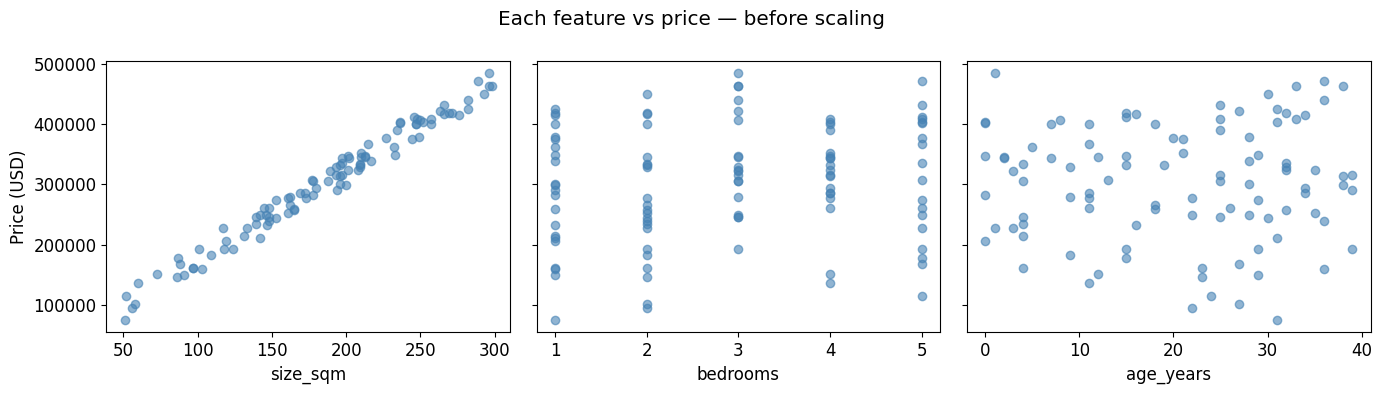

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train, alpha=0.6, color='steelblue')
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (USD)")
fig.suptitle("Each feature vs price — before scaling")
plt.tight_layout()
plt.show()

In [11]:
initial_w = np.zeros(n)
initial_b = 0.

print("=" * 50)
print(f"  alpha = 1e-6  (too large for this data)")
print("=" * 50)
w, b, J_hist_large = gradient_descent(
    X_train, y_train,
    initial_w, initial_b,
    compute_cost, compute_gradient,
    alpha=1e-6, num_iters=100
)
print(f"\nw found: {w}")
print(f"b found: {b:.2f}")

  alpha = 1e-6  (too large for this data)
Iteration     0: Cost 46,429,500,578.1708
Iteration    10: Cost 21,198,697,880.2738
Iteration    20: Cost 9,720,537,842.7076
Iteration    30: Cost 4,498,805,110.1134
Iteration    40: Cost 2,123,280,495.2799
Iteration    50: Cost 1,042,568,479.9966
Iteration    60: Cost 550,899,750.8378
Iteration    70: Cost 327,201,880.9877
Iteration    80: Cost 225,410,850.0987
Iteration    90: Cost 179,078,416.8973

w found: [1571.67552217   24.43665503  151.60122069]
b found: 7.87


In [10]:
print("=" * 50)
print(f"  alpha = 1e-9  (too small)")
print("=" * 50)
w, b, J_hist_small = gradient_descent(
    X_train, y_train,
    initial_w, initial_b,
    compute_cost, compute_gradient,
    alpha=1e-9, num_iters=1000
)
print(f"\nw found: {w}")
print(f"b found: {b:.2f}")

  alpha = 1e-9  (too small)
Iteration     0: Cost 50,218,850,821.0908
Iteration   100: Cost 49,833,573,060.8615
Iteration   200: Cost 49,451,259,449.6134
Iteration   300: Cost 49,071,887,182.5265
Iteration   400: Cost 48,695,433,630.2311
Iteration   500: Cost 48,321,876,337.4573
Iteration   600: Cost 47,951,193,021.6963
Iteration   700: Cost 47,583,361,571.8703
Iteration   800: Cost 47,218,360,047.0147
Iteration   900: Cost 46,856,166,674.9683

w found: [60.70142864  0.87651157  6.03888406]
b found: 0.30


In [7]:
print("=" * 50)
print(f"  alpha = 1e-8  (just right — unscaled)")
print("=" * 50)
w_no_scale, b_no_scale, J_hist_ok = gradient_descent(
    X_train, y_train,
    initial_w, initial_b,
    compute_cost, compute_gradient,
    alpha=1e-8, num_iters=1000
)

print(f"\nw found: {w_no_scale}")
print(f"b found: {b_no_scale:.2f}")

  alpha = 1e-8  (just right — unscaled)
Iteration     0: Cost 50,184,047,124.8826
Iteration   100: Cost 46,463,921,102.4497
Iteration   200: Cost 43,020,342,332.7506
Iteration   300: Cost 39,832,752,781.1727
Iteration   400: Cost 36,882,122,661.1153
Iteration   500: Cost 34,150,836,826.7295
Iteration   600: Cost 31,622,589,611.0218
Iteration   700: Cost 29,282,287,481.5063
Iteration   800: Cost 27,115,958,932.2650
Iteration   900: Cost 25,110,671,074.4727

w found: [513.41398185   7.44979147  50.97741791]
b found: 2.51


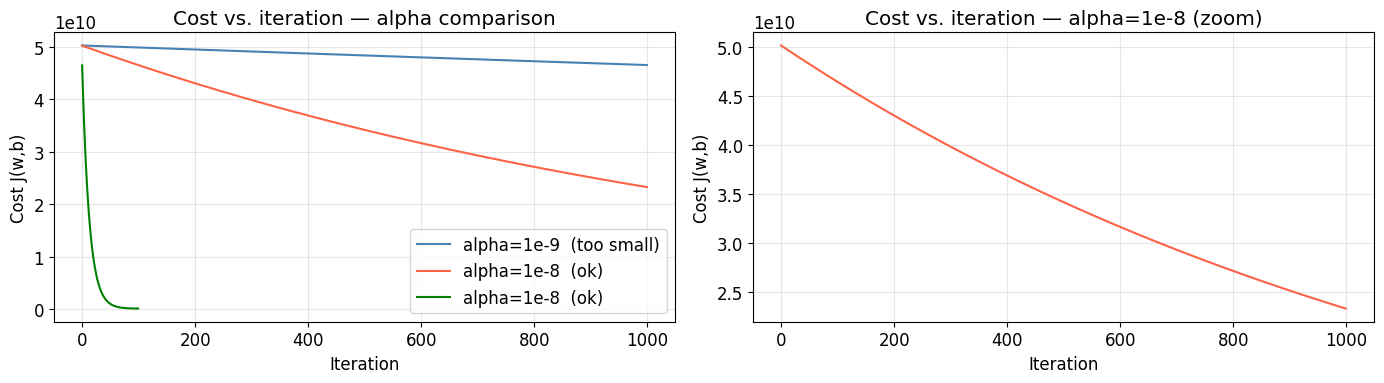

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(J_hist_small, color='steelblue', label='alpha=1e-9  (too small)')
ax1.plot(J_hist_ok,    color='tomato',    label='alpha=1e-8  (ok)')
ax1.plot(J_hist_large,    color='green',    label='alpha=1e-6  (too large)')
ax1.set_title("Cost vs. iteration — alpha comparison")
ax1.set_ylabel("Cost J(w,b)")
ax1.set_xlabel("Iteration")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(J_hist_ok, color='tomato')
ax2.set_title("Cost vs. iteration — alpha=1e-8 (zoom)")
ax2.set_ylabel("Cost J(w,b)")
ax2.set_xlabel("Iteration")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, X_mu, X_sigma = zscore_normalize_features(X_train)
print(f"\nFeature means (should be close to 0): {X_mu}")
print(f"Feature std devs (should be close to 1): {X_sigma}")

print(f"\nPeak to peak range — Raw X    : {np.ptp(X_train, axis=0)}")
print(f"Peak to peak range — Norm X   : {np.ptp(X_norm,  axis=0).round(2)}")
print(f"\nFirst 3 rows — Raw X:\n{X_train[:3]}")
print(f"\nFirst 3 rows — Normalized X:\n{X_norm[:3]}")


Feature means (should be close to 0): [184.99   2.89  20.28]
Feature std devs (should be close to 1): [63.25527567  1.41347091 11.92650829]

Peak to peak range — Raw X    : [247.   4.  39.]
Peak to peak range — Norm X   : [3.9  2.83 3.27]

First 3 rows — Raw X:
[[209.   2.  32.]
 [247.   2.   7.]
 [209.   2.   4.]]

First 3 rows — Normalized X:
[[ 0.37957308 -0.62965569  0.98268493]
 [ 0.98031349 -0.62965569 -1.113486  ]
 [ 0.37957308 -0.62965569 -1.36502651]]


In [15]:
initial_w  = np.zeros(n)
initial_b  = 0.

print("=" * 50)
print("  Gradient descent on NORMALIZED features")
print(f"  alpha = 0.1   (100,000x larger than before!)")
print("=" * 50)

w_norm, b_norm, J_hist_norm = gradient_descent(
    X_norm, y_train,
    initial_w, initial_b,
    compute_cost, compute_gradient,
    alpha=0.1, num_iters=1000
)

print(f"\nw_norm : {w_norm}")
print(f"b_norm : {b_norm:.4f}")

  Gradient descent on NORMALIZED features
  alpha = 0.1   (100,000x larger than before!)
Iteration     0: Cost 40,680,609,371.6556
Iteration   100: Cost  7,775,009.5548
Iteration   200: Cost  7,774,969.2430
Iteration   300: Cost  7,774,969.2430
Iteration   400: Cost  7,774,969.2430
Iteration   500: Cost  7,774,969.2430
Iteration   600: Cost  7,774,969.2430
Iteration   700: Cost  7,774,969.2430
Iteration   800: Cost  7,774,969.2430
Iteration   900: Cost  7,774,969.2430

w_norm : [94535.72121606 11142.7273248  -6496.65047079]
b_norm : 302309.1900


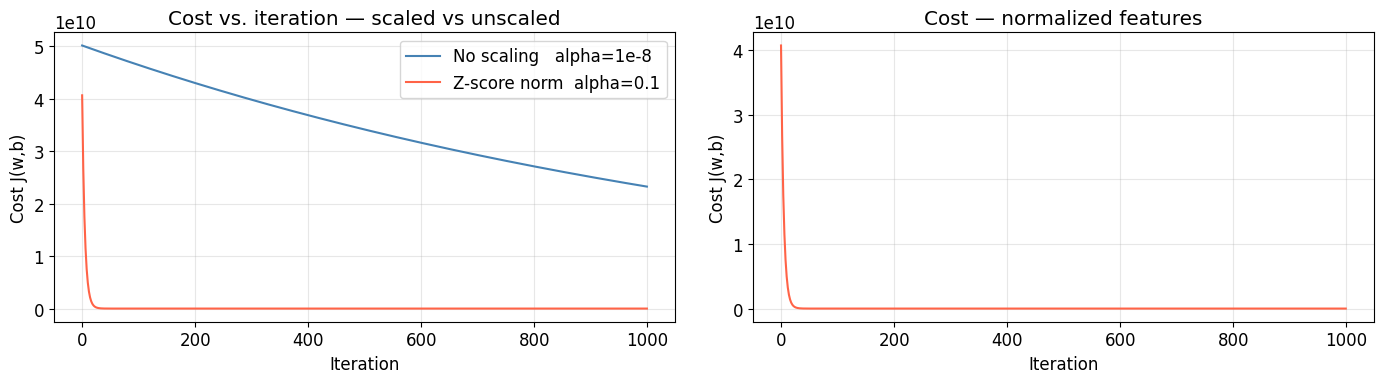

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(J_hist_ok,   color='steelblue', label='No scaling   alpha=1e-8')
ax1.plot(J_hist_norm, color='tomato',    label='Z-score norm  alpha=0.1')
ax1.set_title("Cost vs. iteration — scaled vs unscaled")
ax1.set_ylabel("Cost J(w,b)")
ax1.set_xlabel("Iteration")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(J_hist_norm, color='tomato')
ax2.set_title("Cost — normalized features")
ax2.set_ylabel("Cost J(w,b)")
ax2.set_xlabel("Iteration")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Predict: house of 200 m², 3 bedrooms, 20 years old
x_house      = np.array([200, 3, 20])
x_house_norm = (x_house - X_mu) / X_sigma    # same mu and sigma from training!

y_pred = np.dot(x_house_norm, w_norm) + b_norm

print(f"Input features (original)  : size={x_house[0]}m², "
      f"bedrooms={x_house[1]}, age={x_house[2]}yrs")
print(f"Input features (normalized): {x_house_norm.round(4)}")
print(f"Predicted price            : ${y_pred:,.0f}")

# Predictions vs actual on training set
print(f"\nPredictions vs Actual — training set (first 10 examples):")
print("-" * 60)
for i in range(10):
    pred = np.dot(X_norm[i], w_norm) + b_norm
    print(f"  Prediction: ${pred:>10,.0f}  |  Actual: ${y_train[i]:>10,.0f}  |  "
          f"Diff: ${abs(pred - y_train[i]):>8,.0f}")

Input features (original)  : size=200m², bedrooms=3, age=20yrs
Input features (normalized): [ 0.2373  0.0778 -0.0235]
Predicted price            : $325,761

Predictions vs Actual — training set (first 10 examples):
------------------------------------------------------------
  Prediction: $   324,792  |  Actual: $   328,317  |  Diff: $   3,525
  Prediction: $   395,202  |  Actual: $   399,261  |  Diff: $   4,059
  Prediction: $   340,044  |  Actual: $   332,917  |  Diff: $   7,127
  Prediction: $   459,430  |  Actual: $   462,306  |  Diff: $   2,876
  Prediction: $   226,744  |  Actual: $   227,808  |  Diff: $   1,064
  Prediction: $   365,990  |  Actual: $   362,474  |  Diff: $   3,516
  Prediction: $   405,367  |  Actual: $   402,767  |  Diff: $   2,600
  Prediction: $   354,411  |  Actual: $   348,825  |  Diff: $   5,586
  Prediction: $   284,172  |  Actual: $   285,668  |  Diff: $   1,496
  Prediction: $   290,678  |  Actual: $   290,245  |  Diff: $     433
